# 중간고사 대체 과제

## 문제1. Projection Matrix 해석

이 행렬이 어떤 의미를 가지는지 설명하고, 다음을 포함하여 해석하시오.

- intrinsic 파라미터 (f_x, f_y, c_x, c_y)의 의미

- extrinsic 파라미터 (R, t)의 역할

- 이 행렬이 3D 점을 이미지 좌표로 어떻게 변환하는지 수식으로 설명

## 답변1. 
- 세계 좌표(Object frame) → Extrinsic 변환 (To) → 카메라 좌표(Camera frame)
- 카메라 좌표(Camera frame) → Intrinsic 변환 (K) → 이미지 픽셀 좌표(Image points)


(의자 그림을 통해 3D -> 2D 좌표계 변환 흐름을 좀 더 가시적으로 보여드리겠습니다.)

<img src="projection.png" width="350">

Projection Matrix(투영 행렬)는 3차원 세계 좌표계(World)의 점을 2차원 이미지 좌표계(Image pixel)로 매핑해주는 수학적 도구입니다. 이는 카메라의 물리적 위치(외부 파라미터)와 카메라 렌즈 및 센서의 특성(내부 파라미터)을 하나로 통합한 행렬입니다.

Intrinsic 파라미터 (fx,fy,cx,cy)는 카메라의 내부 정보를 담고 있으며, 카메라 좌표계의 점을 픽셀 좌표로 변환할 때 사용됩니다. 조금 더 구체적으로 설명하자면, 
- fx,fy (Focal Length)는 렌즈의 초점 거리입니다. 물리적인 거리가 아닌 픽셀 단위로 표현되며, 이미지의 확대/축소 비율에 영향을 줍니다.(참고로 fx는 가로 방향, fy는 세로 방향을 의미합니다.) 
- cx,cy (Principal Point)는 주점 또는 광학 중심이라고 하며, 카메라의 광학축이 이미지 센서와 만나는 지점의 픽셀 좌표입니다. 일반적으로 이미지의 중앙 근처에 위치합니다.

Extrinsic 파라미터 (R,t)의 역할은 카메라가 세계 어디에, 어떤 방향으로 설치되어 있는지를 나타냅니다. 
- R (Rotation Matrix)은 세계 좌표계의 축들이 카메라가 바라보는 방향과 일치하도록 카메라 좌표계의 축들과 정렬되도록 회전시키는 3x3 행렬입니다. 
- t (Translation Vector)는 세계 좌표계의 원점에서 카메라 좌표계의 원점까지의 이동 거리를 나타내는 3x1 벡터입니다.

( 투과되는 그림을 통해 실제 카메라 내부의 Intrinsic 파라미터의 기하학적인 의미를 보여드리겠습니다.  )
- 주점(Cx,Cy)의 위치가 이미지 평면의 중심에 정확히 표시되어 있습니다.
- 초점 거리(f)가 광학축(optical axis)을 따라 표시되어 있습니다.
- 픽셀 좌표(u,v)가 이미지 평면 위에서 어떻게 정의되는지 직관적으로 보여줍니다.
  
<img src="pinhole camera.png" width="350">

###  3D 점을 이미지 좌표로 변환하는 수식 과정

3차원 세계 좌표 Pw=[Xw,Yw,Zw,1]T를 2차원 이미지 픽셀 p=[u,v,1]T로 변환하는 과정은 다음과 같습니다.


여기서 과정을 단계별로 나누면:

1. 세계 좌표 (Pw) → 카메라 좌표 변환 (Pc):          <img src="camera_pixel.png" width="150">

2. 카메라 좌표 → 정규 이미지 좌표 변환:
   
                카메라 좌표 [Xc,Yc,Zc]를 깊이 값 Zc로 나누어 정규 좌표 [x′,y′,1]을 얻습니다. 
3. 정규 좌표 → 이미지 픽셀 좌표 변환 (p):
                   
                   최종적으로 내부 파라미터 Matrix A를 곱하여 픽셀 위치를 구합니다.
    
     <img src="u,v pixels.png" width="150">
    
    <img src="coordinate.png" width="150">


## 문제2. Projection Matrix를 이용한 3D → 2D 투영
+ 임의의 3차원 점들을 생성하고, projection matrix를 이용하여 이미지 좌표로 투영하시오.
+ 투영된 점들을 이미지 위에 시각화하고, 결과가 카메라 투영의 특성과 어떻게 일치하는지 설명하시오

## 답변2 
  1. 임의의 3차원 점 생성하기
  2. Projection Matrix(P2) 가져오기
      - KITTI sequence09 데이터셋의 calib.txt 파일 (색깔 왼쪽 카메라 -image_02 사용)
      - 왼쪽 3x3 부분: 카메라의 초점거리(fx,fy)와 주점(cx,cy) 정보를 담고 있습니다.
      - 맨 오른쪽 4번째 열: 카메라의 위치(Translation)와 관련된 정보입니다.
        (KITTI에서는 기준 카메라로부터의 상대적 위치)
                                                      
        ![alt text](p2.png)
  3. 수식으로 투영 계산 (3D → 2D)
      - 생성한 3D 점에 투영 행렬 P를 곱합니다.  
         
          ![alt text](3D.png)

      - 그 후, 결과값의 첫 번째(u⋅s)와 두 번째(v⋅s) 원소를 세 번째 원소(s)로 나누어 최종 픽셀 좌표(u,v)를 얻습니다.

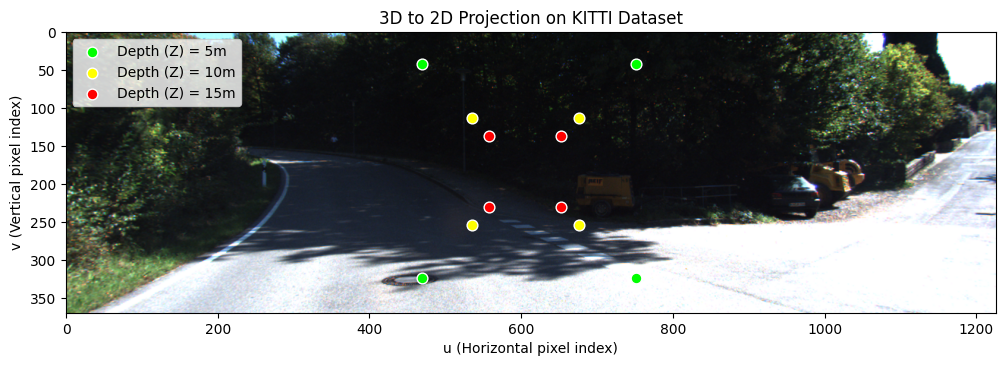

In [17]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# --- 경로 설정 (상대 경로로 통일) ---
calib_path = './data_odometry_color/dataset/sequences/09/calib.txt'
image_path = './data_odometry_color/dataset/sequences/09/image_2/000000.png'

# ---  KITTI calib.txt에서 P2 행렬을 읽어오는 함수 ---
def read_kitti_calib(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if line.startswith('P2:'):
                # 'P2:' 글자를 제외하고 숫자만 추출
                p2_data = line.replace('P2:', '').strip().split()
                p2_flat = np.array(p2_data, dtype=np.float32)
                return p2_flat.reshape(3, 4)
    return None

# 1. 임의의 3D 점 생성 (카메라 앞 5m, 10m, 15m에 있는 점들)
# [X, Y, Z, 1] 형태
points_3d = np.array([
    # Z = 5m (카메라와 가장 가까움 -> 이미지에서 크게 보임)
    [1, 1, 5, 1], [-1, 1, 5, 1], [1, -1, 5, 1], [-1, -1, 5, 1],
    
    # Z = 10m (중간 거리)
    [1, 1, 10, 1], [-1, 1, 10, 1], [1, -1, 10, 1], [-1, -1, 10, 1],
    
    # Z = 15m (카메라와 가장 멈 -> 이미지에서 작게 보임)
    [1, 1, 15, 1], [-1, 1, 15, 1], [1, -1, 15, 1], [-1, -1, 15, 1]
])

# 2. KITTI Projection 행렬 설정 (calib.txt에서 가져온 값)
P2 = read_kitti_calib(calib_path)

# 3. 2D 투영 계산
# @는 행렬 곱하기 연산입니다. T는 전치(Transpose)입니다.
points_2d_homo = P2 @ points_3d.T

# 동차 좌표를 일반 좌표로 변환 (마지막 행으로 나누기)
u = points_2d_homo[0, :] / points_2d_homo[2, :]
v = points_2d_homo[1, :] / points_2d_homo[2, :]

# 4. 시각화 (KITTI Seq 09의 첫 번째 이미지 로드)
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.imshow(img)
# 거리별로 나누어 시각화 (u, v 배열의 인덱스 활용)
plt.scatter(u[0:4], v[0:4], c='lime', s=60, edgecolors='white', label='Depth (Z) = 5m')
plt.scatter(u[4:8], v[4:8], c='yellow', s=60, edgecolors='white', label='Depth (Z) = 10m')
plt.scatter(u[8:12], v[8:12], c='red', s=60, edgecolors='white', label='Depth (Z) = 15m')

plt.title("3D to 2D Projection on KITTI Dataset")
plt.xlabel("u (Horizontal pixel index)")
plt.ylabel("v (Vertical pixel index)")

plt.legend(loc='upper left')
plt.show()

## 결과 해석 및 카메라 투영 특성 분석
위의 시각화 결과는 임의로 생성한 3차원 점들이 KITTI 데이터셋의 Projection Matrix(P)를 통해 2차원 이미지 평면에 성공적으로 투영되었음을 보여줍니다. 이 결과는 다음과 같은 카메라 투영의 핵심 특성들을 잘 나타내고 있습니다.
1. 원근 투영 효과 (Perspective Projection Effect)
   + 동일한 간격을 가진 3D 점들이라도 카메라에서 멀어질수록(Z값 증가) 이미지 중심으로 모이며 점 사이의 간격이 좁게 나타납니다. Z값에 반비례하여 픽셀 좌표가 결정되는 원근 투영의 특성을 잘 보여줍니다.이는 "멀리 있는 물체는 작게 보인다"는 원근법의 원리와 일치합니다.
2. 주점(Principal Point)으로의 수렴
   + 3D 점들이 무한히 멀어질 경우(Z→∞), 모든 투영점은 결국 주점(cx,cy) 좌표로 수렴하게 되는데, 시각화된 점들이 중앙을 향해 모여드는 모습에서 이 특성을 확인할 수 있습니다.
 3. 3D 공간 구조의 2D 보존 
    + 투영 계산 과정에서 Z값으로 나누는 과정(Normalization)이 포함되는데, 이로 인해 실제 3D 세계의 거리 단위가 2D 픽셀 단위로 변환되며 깊이 정보가 소실되지만 3D 공간 상의 상하좌우 위치 관계는 유지됩니다.
4. 가시 영역(Field of View)과 깊이 유효성 반영
   + 투영 영역이 Z>0인 점들만 이미지 평면에 나타나며, 카메라 뒤에 있는 점(Z<0)은 투영되지 않는 실제 카메라의 물리적 제계가 수식에서도 그대로 반영됩니다.


## 문제3. Pose를 이용한 차량 궤적 시각화
KITTI pose 데이터를 이용하여 1번 카메라(차량)의 이동 궤적을 시각화하시오.

- 각 프레임의 카메라 위치를 추출하여 2D 또는 3D로 표현
- 초기 프레임을 기준 좌표계로 설정
- 차량의 이동 방향과 속도에 대해 간단히 설명

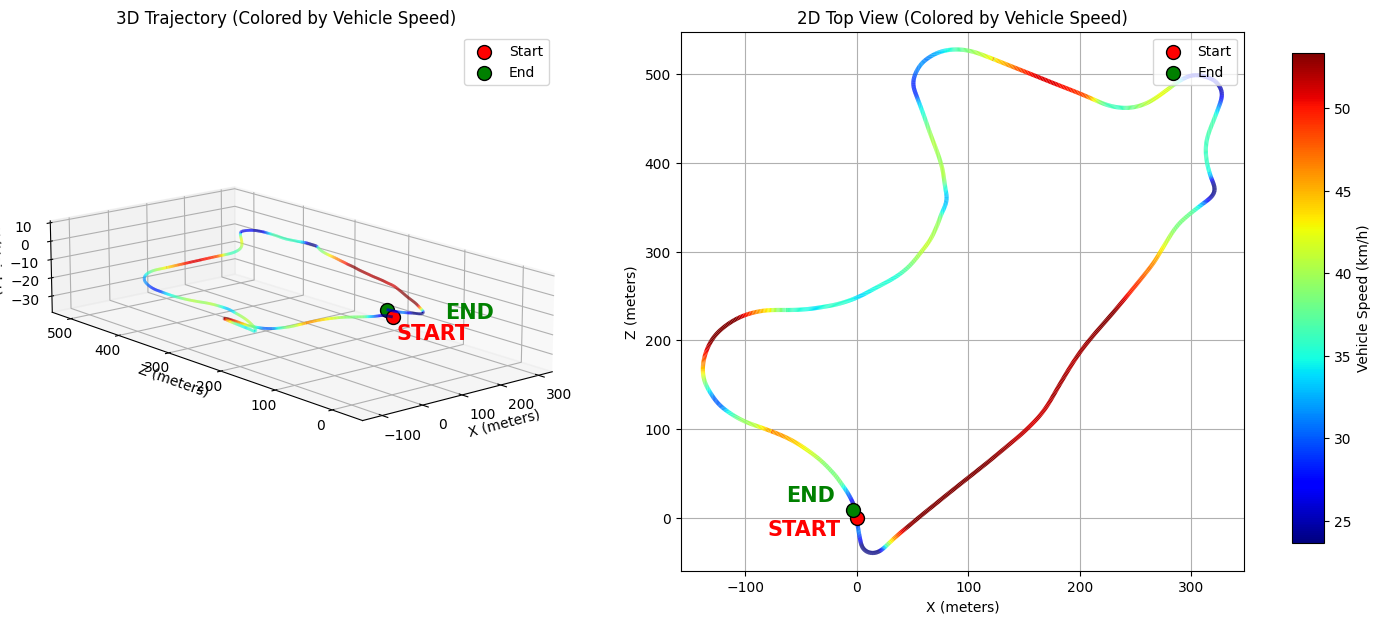

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection

base_path = './dataset/poses/'
seq = '09' # 테스트로 09번 시퀀스 사용
file_path = os.path.join(base_path, f'{seq}.txt')

# 데이터 읽기 및 3x4 행렬 변환
poses = pd.read_csv(file_path, delimiter=' ', header=None)
gt = np.zeros((len(poses), 3, 4))
for i in range(len(poses)):
    gt[i] = np.array(poses.iloc[i]).reshape((3, 4))

# 위치 좌표 추출 (x, y, z)
x = gt[:, 0, 3]
y = gt[:, 1, 3]
z = gt[:, 2, 3]

# --- [속도 및 이동 방향 분석] ---
# 프레임 간 직선 거리 계산
dists = np.sqrt(np.diff(x)**2 + np.diff(y)**2 + np.diff(z)**2)
# KITTI 데이터는 보통 10Hz(초당 10프레임)이므로 속도(m/s)를 구할 수 있습니다.
speeds = dists * 10* 3.6
speeds = np.append(speeds, speeds[-1])
# 속도 차이 정규화 (Robust Scaling)
v_min, v_max = np.percentile(speeds, [5, 95])
norm = plt.Normalize(v_min, v_max)

# 3D 선분 생성
points_3d = np.array([x, z, y]).T.reshape(-1, 1, 3)
segments_3d = np.concatenate([points_3d[:-1], points_3d[1:]], axis=1)

# 2D 선분 생성 (X-Z 평면)
points_2d = np.array([x, z]).T.reshape(-1, 1, 2)
segments_2d = np.concatenate([points_2d[:-1], points_2d[1:]], axis=1)

# --- [그래프] ---
fig = plt.figure(figsize=(16, 7))

# 3D 궤적 
ax1 = fig.add_subplot(121, projection='3d')
lc3d = Line3DCollection(segments_3d, cmap='jet', norm=norm)
lc3d.set_array(speeds)
lc3d.set_linewidth(2)
line3d = ax1.add_collection(lc3d)

ax1.scatter(x[0], z[0], y[0], color='red', s=100, label='Start',edgecolors='black', zorder=10) # 시작점
ax1.scatter(x[-1], z[-1], y[-1], color='green', s=100, label='End',edgecolors='black', zorder=10)  # 끝점

ax1.text(x[0]- 5, z[0]-10, y[0]-10 , 'START', color='red', fontsize=15, fontweight='bold')
ax1.text(x[-1]- 5, z[-1]-100, y[-1] + 5, 'END', color='green', fontsize=15, fontweight='bold')
# 3D 축 범위 설정
ax1.set_xlim(x.min(), x.max())
ax1.set_ylim(z.min(), z.max())
ax1.set_zlim(y.min() - 5, y.max() + 5) 

# 3D 박스 비율 설정 (평면 이동량에 비해 높이 변화가 적으므로 높이를 강조)
ax1.set_box_aspect([1, 2, 0.4]) 

ax1.set_xlabel('X (meters)')
ax1.set_ylabel('Z (meters)')
ax1.set_zlabel('Y (Height)')
ax1.set_title(f'3D Trajectory (Colored by Vehicle Speed)')

ax1.legend()
# 보기 좋은 각도로 조정
ax1.view_init(elev=15, azim=-130)

# 2D (Top View)
ax2 = fig.add_subplot(122)
lc2d = LineCollection(segments_2d, cmap='jet', norm=norm)
lc2d.set_array(speeds)
lc2d.set_linewidth(3)
line2d = ax2.add_collection(lc2d)

ax2.scatter(x[0], z[0], color='red', s=100, label='Start', edgecolors='black', zorder=5)
ax2.scatter(x[-1], z[-1], color='green', s=100, label='End', edgecolors='black', zorder=5)

ax2.text(x[0]- 80, z[0]-20, 'START', color='red', fontsize=15, fontweight='bold')
ax2.text(x[-1]- 60, z[-1]+10, 'END', color='green', fontsize=15, fontweight='bold')

ax2.set_xlim(x.min()-20, x.max()+20)
ax2.set_ylim(z.min()-20, z.max()+20)
ax2.set_xlabel('X (meters)')
ax2.set_ylabel('Z (meters)')
ax2.set_title('2D Top View (Colored by Vehicle Speed)')
ax2.grid(True)
ax2.legend()

cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7]) # 컬러바 위치 설정
cbar = fig.colorbar(line2d, cax=cbar_ax)
cbar.set_label('Vehicle Speed (km/h)')

plt.show() 

## 답변3
1. 속도 분포의 시각적 이해
   - 그래프에서 붉은색 구간은 속도가 높은 구간(직선 주행)이고, 푸른색 구간은 속도가 낮은 구간(커브길이나 정지 전후)임을 알 수 있습니다.
   - Sequence 09 결과를 보면, 직선 구간에서는 속도가 올라가다가 급격한 회전 구간(U턴에 가까운 왼쪽 커브)에서 선의 색깔이 파란색으로 변하며 감속했음을 명확히 확인할 수 있습니다.
2. 가속 및 감속 패턴
   - 출발 지점(Start) 주변에서 색상이 점진적으로 변하는 것을 통해 차량의 가속 과정을 확인할 수 있으며, 도착 지점(End) 근처에서 다시 푸른색으로 변하는 것을 통해 정차를 위한 감속 과정을 분석할 수 있습니다.
3. 데이터의 물리적 타당성
   - 시각화에 사용된 속도 데이터는 KITTI 데이터셋의 10Hz 샘플링 주기를 반영하여 프레임 당 이동 거리를 km/h 단위의 절대 속도로 변환한 결과입니다.
   - 계산된 속도가 시속 약 20~50km/h 사이에서 형성되는 것을 통해, 해당 시퀀스가 도심지나 주택가에서 촬영된 실제 주행 데이터임을 수학적으로 증명할 수 있습니다.

## 문제4. Projection Matrix를 활용한 차선 해석
Bayesian 분류 결과로 얻은 도로 영역을 이용하여 차선 후보를 추출하고, 이를 projection matrix와 연관 지어 해석하시오. 다음 내용을 포함하시오.
- 이미지 좌표에서 검출된 차선이 카메라 좌표계에서 어떤 의미를 가지는지 설명
- 도로가 평면(ground plane)이라고 가정할 때 차선의 기하적 특성 설명
- projection matrix가 차선의 기울기, 소실점(vanishing point)과 어떤 관계가 있는지 설명


## 답변4
#### 1. 이미지 좌표에서 검출된 차선이 카메라 좌표계에서 가지는 의미
베이지안 분류 결과(붉은색 오버레이 영역)의 경계선이 곧 차선 후보가 됩니다. 

<img src="overlay_000120.png" width="450">

<img src="overlay_000355.png" width="450">
    

*   **이미지 해석:** 이미지 좌표 $p=(u, v)$에서 검출된 차선은 카메라 좌표계 $Pc=(Xc, Yc, Zc)$에서 볼 때, 카메라 광심(Optical Center)으로부터 뻗어 나가는 **특정한 3차원 반직선**들의 집합을 의미합니다.
*   **의미:** 단순히 2차원 그림이 아니라, 카메라가 바라보는 3차원 공간상의 '길'이 투영된 결과입니다. 투영 행렬 $P$의 역산(Back-projection)을 통해 이미지 상의 차선 픽셀이 실제 세계의 어느 방향에 위치한 지점인지 결정할 수 있습니다.

#### 2. 도로가 평면(Ground Plane)이라고 가정할 때 차선의 기하적 특성
도로를 하나의 무한한 평면으로 가정할 때, 3차원 공간상의 차선과 2차원 이미지 평면 사이에는 다음과 같은 결정적인 기하학적 특성이 성립합니다.

1. 3D 공간에서의 상호 평행성 및 간격의 일정성
    - 특성: 실제 3차원 세계(카메라 좌표계)에서 좌우 차선은 서로 만나지 않는 완벽한 평행선이며, 두 선 사이의 거리(Lane Width)는 주행 방향인 Z축의 깊이에 관계없이 일정하게 유지됩니다.
    - 의미: 이 특성은 차선 검출 알고리즘에서 매우 중요한 '제약 조건(Constraint)'이 됩니다. 만약 검출된 두 선이 3D 복원 시 평행하지 않다면, 그것은 차선이 아니거나 오검출임을 판별하는 근거가 됩니다.

2. 2D 이미지에서의 소실점 수렴 
    - 특성: 3D 공간의 평행한 차선들은 투영 행렬(P)에 의해 이미지 평면으로 투영될 때, 멀어질수록 간격이 좁아지며 결국 지평선 위의 한 점인 **소실점(Vanishing Point)**으로 모이게 됩니다.
    - 의미: 이미지 상에서 차선의 기울기는 소실점의 위치에 의해 결정됩니다. 베이지안 도로 분류기에서 사다리꼴 마스크를 사용하는 이유는 바로 이 '평행선의 수렴'이라는 원근 왜곡을 기하학적으로 모델링한 결과입니다.

3. 픽셀 좌표와 3D 거리의 1:1 매핑
    - 특성: 일반적인 이미지에서는 깊이 정보(Z)가 소실되어 한 픽셀이 3D 공간의 어느 지점인지 알 수 없습니다. 그러나 **"모든 차선은 지면(평면) 위에 있다"**는 가정을 도입하면, 카메라의 설치 높이(H)와 각도를 이용해 이미지의 (u,v)좌표를 실제 세계의 (X,Z)거리로 1:1 변환할 수 있습니다.
    - 의미: 이를 통해 이미지에서 휘어져 보이는 차선의 실제 곡률을 계산하거나, 앞차와의 거리를 미터(meter) 단위로 정밀하게 측정할 수 있게 됩니다.

#### 3. Projection Matrix와 차선의 기울기, 소실점의 관계
투영 행렬 $P$는 3차원의 평행한 기하 구조가 2차원의 사다리꼴 형태로 변환되는 과정에서 발생하는 원근 왜곡을 수학적으로 정의합니다. 우리는 이 행렬을 역이용하여 이미지 상의 2차원 도로 영역으로부터 실제 도로의 폭, 방향, 거리와 같은 물리적 실체를 복원할 수 있습니다.
*   **소실점의 결정:**
    * 3D 공간에서 도로의 방향 벡터를 $D = [0, 0, 1, 0]^T$ (무한히 먼 곳)라고 할 때, 이미지 상의 소실점 $v$는 $v = P \cdot D$로 계산됩니다.
    *   즉, **Projection Matrix는 3D 세계의 '무한한 평행'이 이미지 상의 어느 좌표($c_x, c_y$ 근처)에서 만날지를 결정**합니다. 베이지안 코드의 `vp_y_rate` 파라미터가 바로 투영 행렬에 의해 결정되는 소실점의 높이를 의미합니다.
    *   차량이 흔들리거나 도로의 경사도가 변하면 투영 행렬에 의해 계산되는 소실점의 위치도 실시간으로 이동하게 됩니다.
*   **차선의 기울기 형성:**
    *   이미지 상에서 차선의 기울기는 Projection Matrix의 내부 파라미터($f_x, f_y$)와 외부 파라미터(카메라의 설치 각도$R, 위치t$)에 의해 결정됩니다.
    *   카메라가 지면과 수평이라면 '차선'은 소실점을 향해 대칭적으로 모입니다. 차량이 흔들리거나 도로의 경사로 인해 카메라가 기울어져 각도가 변하면, 투영 행렬 값이 변하게 되어 이미지 상의 차선 기울기도 급격히 변합니다.
*   **수학적 역추적과 복원 관계:** 
    *   투영 행렬 $P$를 알면 이미지 좌표계에서 추출된 도로의 경계선을 보고 실제 도로의 곡률이나 카메라와의 상대적 각도를 역추적할 수 있습니다.
    *   이는 베이지안 분류기로 얻은 2차원 사다리꼴 영역의 경계선들이 단순한 픽셀의 나열이 아니라, 투영 행렬$P$에 의한 원근 변환의 결과입니다.


## HSV 기반 Bayesian 도로 분할 + Canny & Hough Transform

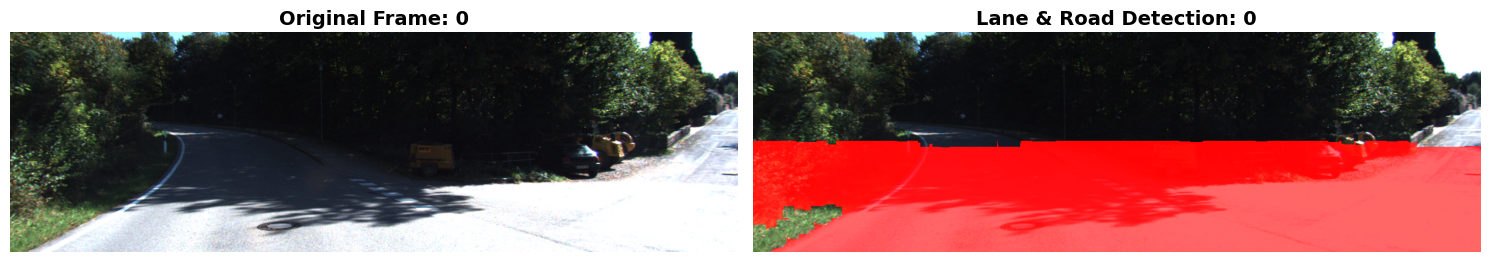

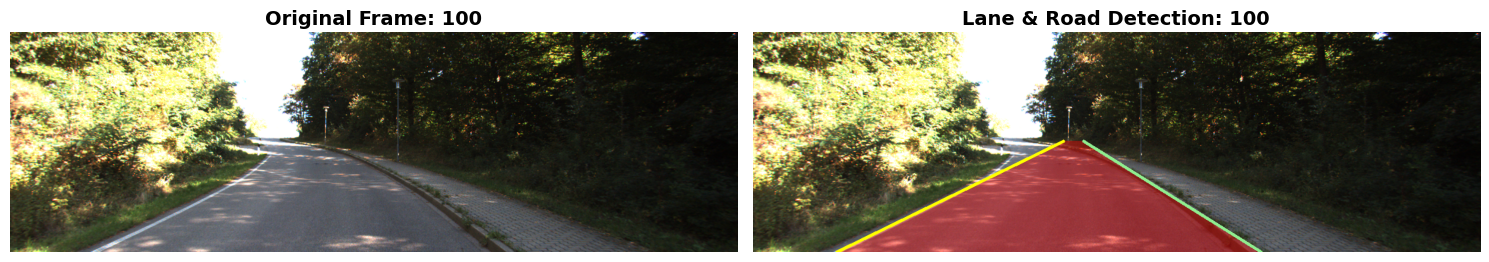

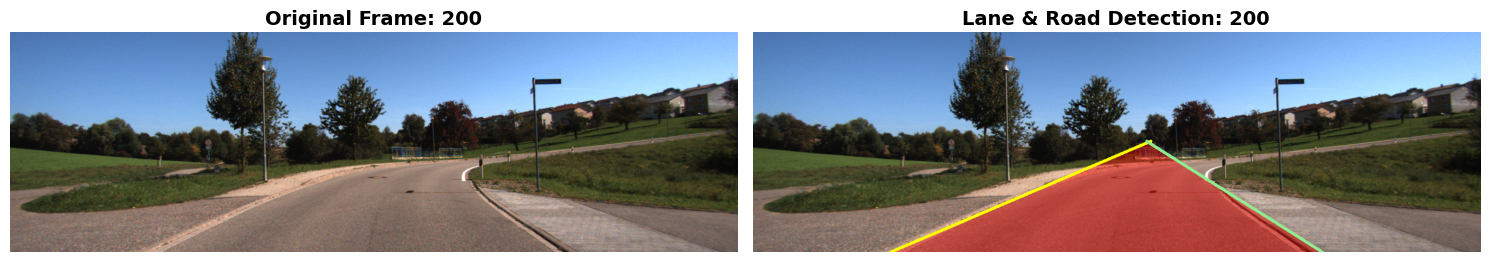

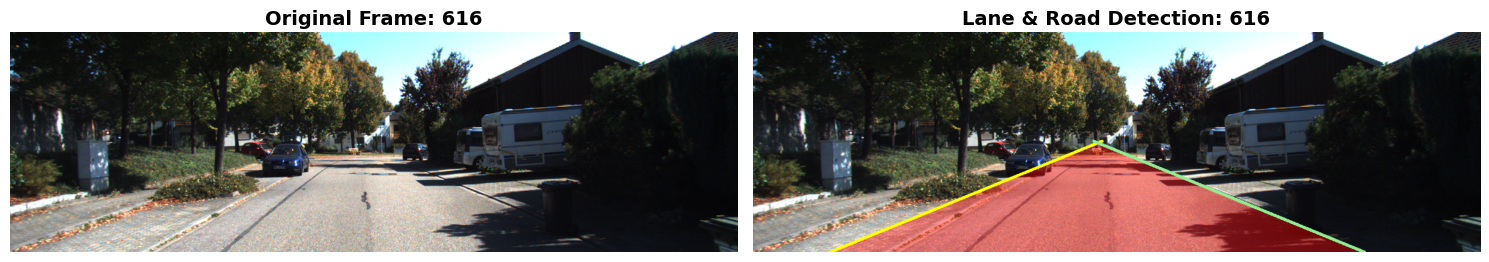

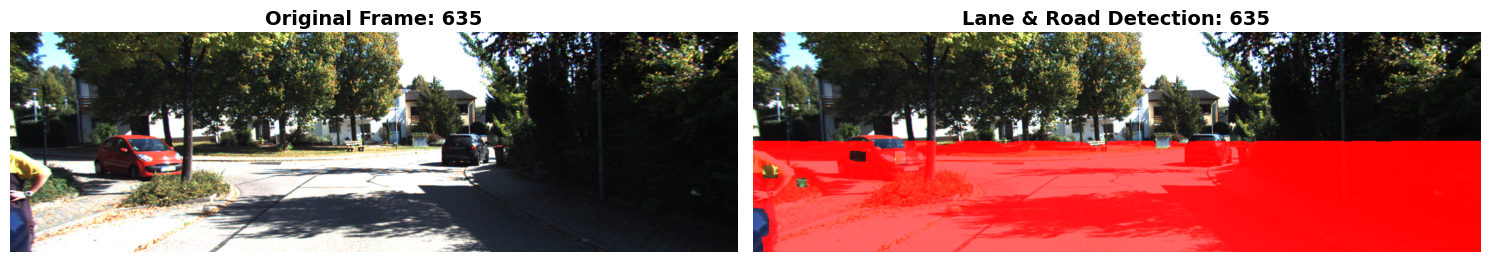

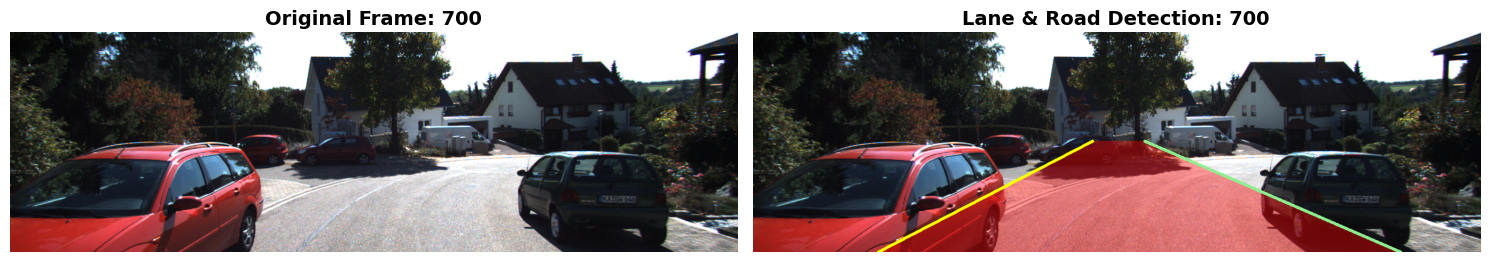

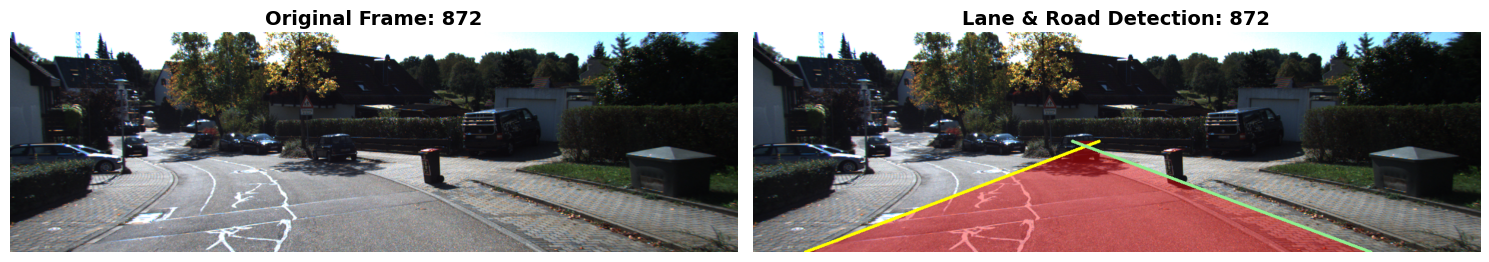

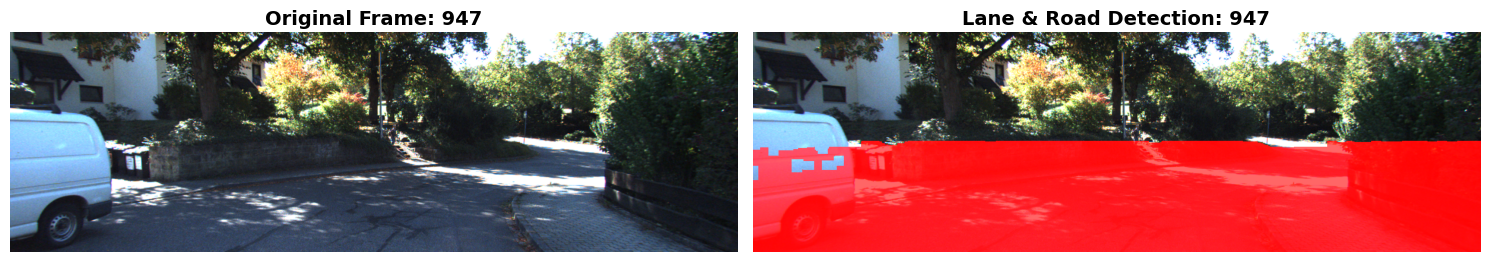

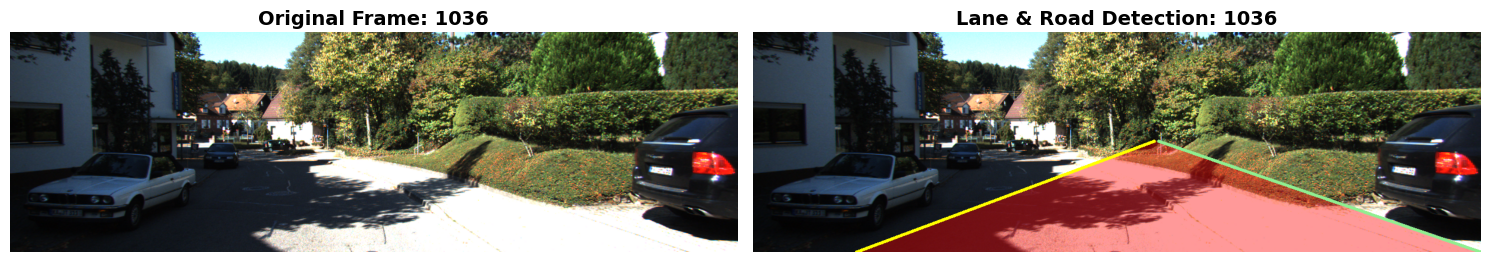

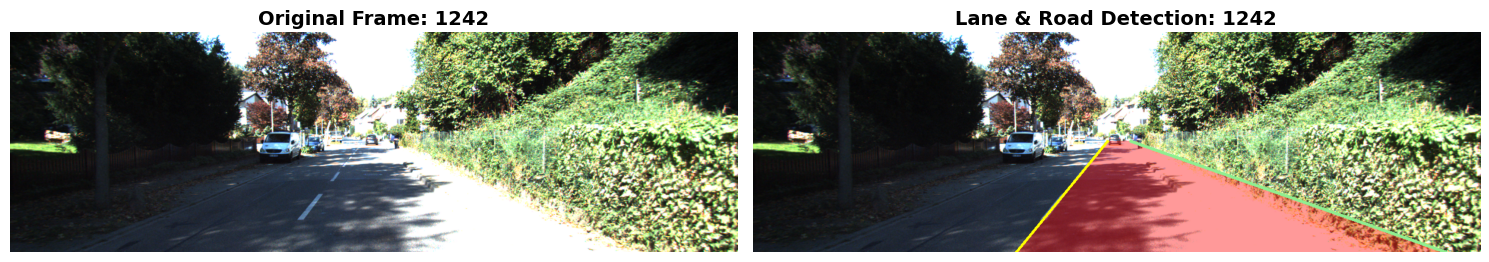

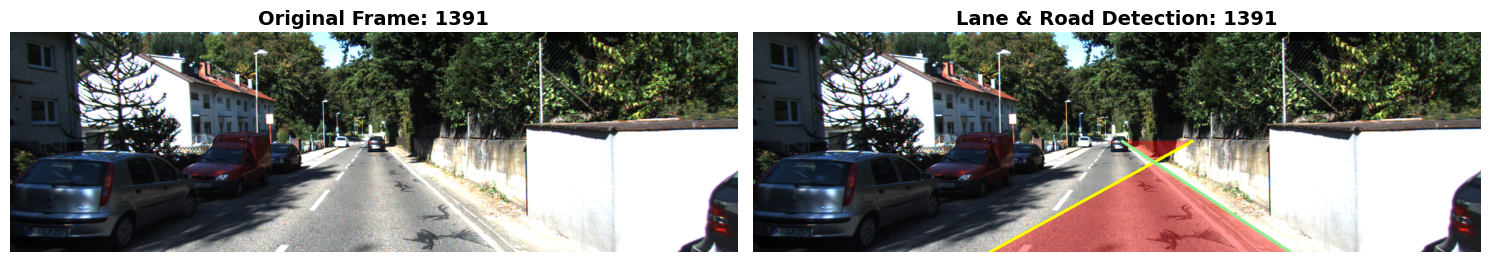

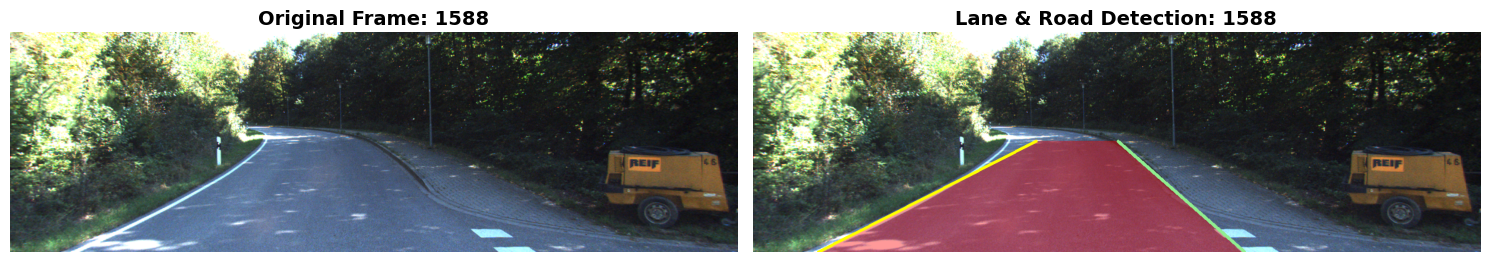

이미지 프레임 저장 완료: outputs\bayes_road_09_projection\frames
비디오 저장 완료: outputs\bayes_road_09_projection\road_detection_09.mp4


In [12]:
#!/usr/bin/env python3
"""
Bayesian 도로 분류기 - Projection Matrix 기반 사다리꼴 + HSV 그림자 보정
 1. Calib 파일에서 P2 행렬을 읽고 소실점 계산
 2. Projection Matrix 기반 사다리꼴 마스크 생성
 3. 베이지안 통계 기반 도로 픽셀 분류
 4. Hough 변환으로 차선 검출 및 소실점 수렴 필터링
 5. 검출된 선들의 평균을 구하고 바닥부터 소실점까지 연장
"""
import math
from pathlib import Path
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from typing import List, Tuple

def list_frames(data_root: Path) -> List[Path]:
    return sorted(data_root.glob("*.png"))

def get_vp_from_calib(calib_path: Path) -> Tuple[int, int]:
    with open(calib_path, 'r') as f:
        for line in f:
            if line.startswith('P2:'):
                p2_data = np.array([float(x) for x in line.split()[1:]]).reshape(3, 4)
                break
    v_h = p2_data[:, 2]
    vp_x = int(v_h[0] / v_h[2])
    vp_y = int(v_h[1] / v_h[2])
    return vp_x, vp_y

def get_trapezoid_mask(width: int, height: int, vp_x: int, vp_y: int):
    """통계 학습을 위한 초기 사다리꼴 ROI 마스크"""
    mask = np.zeros((height, width), dtype=np.uint8)
    p1 = [vp_x - int(width * 0.05), vp_y]
    p2 = [vp_x + int(width * 0.05), vp_y]
    p3 = [int(width * 0.85), height]
    p4 = [int(width * 0.15), height]
    cv2.fillPoly(mask, [np.array([p1, p2, p3, p4], np.int32)], 1)
    return mask, (1 - mask).astype(np.uint8)

def get_bayesian_mask(img_hsv: np.ndarray, road_p: np.ndarray, bg_p: np.ndarray, 
                      prior_road: float, vp_y: int) -> np.ndarray:
    """베이지안 통계 기반 도로 픽셀 분류 (그림자 및 채도 보정 통합)"""
    h, w, _ = img_hsv.shape
    eps = 1e-10
    
    # 1. 베이지안 로그 우도 계산
    log_p_road = np.full((h, w), math.log(prior_road + eps))
    log_p_bg = np.full((h, w), math.log(1 - prior_road + eps))
    
    # H, S, V 채널별 가중치 적용 (V는 그림자 영향으로 낮게 설정)
    weights = [1.2, 1.2, 0.6]
    for c in range(3):
        log_p_road += weights[c] * np.log(road_p[img_hsv[:,:,c], c] + eps)
        log_p_bg += weights[c] * np.log(bg_p[img_hsv[:,:,c], c] + eps)
    
    mask = (log_p_road > log_p_bg).astype(np.uint8)
    mask[:vp_y + 10, :] = 0 
    # 2. 보정: 너무 높은 채도(나무/하늘) 제거 및 그림자 영역 복구
    s_channel = img_hsv[:, :, 1]
    v_channel = img_hsv[:, :, 2]
    
    mask[s_channel > 100] = 0 # 채도 필터
    shadow = ((v_channel < 100) & (s_channel < 50)).astype(np.uint8) # 그림자 추정
    shadow[:vp_y, :] = 0 # 하늘 제외
    
    mask = cv2.bitwise_or(mask, shadow)
    
    # 3. 노이즈 제거 (모폴로지)
    kernel = np.ones((15, 15), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask > 0

def detect_lanes(img_rgb: np.ndarray, vp_x: int, vp_y: int):
    """Hough 변환으로 차선 검출 및 소실점 수렴 필터링"""
    h, w = img_rgb.shape[:2]
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)
    
    # ROI 제한 (소실점 근처 하단만)
    roi = np.zeros_like(edges)
    pts = np.array([[0, h], [vp_x-100, vp_y], [vp_x+100, vp_y], [w, h]])
    cv2.fillPoly(roi, [pts], 255)
    edges = cv2.bitwise_and(edges, roi)
    
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=60, maxLineGap=100)
    left_lines, right_lines = [], []
    
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if x1 == x2: continue
            slope = (y2 - y1) / (x2 - x1)
            # 기울기에 따라 좌/우 분류 (KITTI 기준)
            if slope < -0.3: left_lines.append(line[0])
            elif slope > 0.3: right_lines.append(line[0])
            
    return left_lines, right_lines

def get_average_line(lines, h, vp_y):
    """검출된 선들의 평균을 구하고 바닥부터 소실점까지 연장"""
    if not lines: return None
    x1s, y1s, x2s, y2s = zip(*lines)
    avg_line = [np.mean(x1s), np.mean(y1s), np.mean(x2s), np.mean(y2s)]
    
    # 선 연장 (Extrapolation)
    x1, y1, x2, y2 = avg_line
    slope = (x2 - x1) / (y2 - y1 + 1e-5)
    x_bottom = int(x1 + slope * (h - y1))
    x_top = int(x1 + slope * (vp_y - y1))
    return (x_bottom, h), (x_top, vp_y)

def run( data_root: Path, out_dir: Path, video_name: str, prior_road: float,alpha=0.85,fps=10.0 ):
    img_dir = data_root / "image_2"
    calib_path = data_root / "calib.txt"
    frames = sorted(img_dir.glob("*.png"))
        
    vp_x, vp_y = get_vp_from_calib(calib_path)
    sample = np.array(Image.open(frames[0]))
    h, w = sample.shape[:2]
    road_mask, bg_mask = get_trapezoid_mask(w, h, vp_x, vp_y)
    
    # 1. 소실점 및 마스크 초기화
    out_dir.mkdir(parents=True, exist_ok=True)
    frames_save_dir = out_dir / "frames"
    frames_save_dir.mkdir(parents=True, exist_ok=True)
    
    video_path = str(out_dir / video_name)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_writer = cv2.VideoWriter(video_path, fourcc, fps, (w, h))
    
    road_p_total = np.ones((256, 3))
    bg_p_total = np.ones((256, 3))

    for idx, path in enumerate(frames):
        img = np.array(Image.open(path).convert('RGB'))
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        
        # 2. 도로 픽셀값 통계 업데이트
        for c in range(3):
            road_p_total[:, c] = alpha * road_p_total[:, c] + (1-alpha) * np.bincount(hsv[road_mask>0, c], minlength=256)
            bg_p_total[:, c] = alpha * bg_p_total[:, c] + (1-alpha) * np.bincount(hsv[bg_mask>0, c], minlength=256)
        
        road_p = road_p_total / road_p_total.sum(axis=0)
        bg_p = bg_p_total / bg_p_total.sum(axis=0)
        
        # 3. 차선 검출 (Hough)
        l_lines, r_lines = detect_lanes(img, vp_x, vp_y)
        l_avg = get_average_line(l_lines, h, vp_y)
        r_avg = get_average_line(r_lines, h, vp_y)
        
        overlay = img.copy()
        
        # 4. 출력 로직 (차선 우선 -> 실패 시 베이지안)
        if l_avg and r_avg:
            # --- 1순위: 두 차선 사이를 빨간색으로 채우기 ---
            poly_pts = np.array([l_avg[0], l_avg[1], r_avg[1], r_avg[0]], np.int32)
            temp_fill = img.copy()
            cv2.fillPoly(temp_fill, [poly_pts], (255, 0, 0)) # Red Fill
            cv2.addWeighted(temp_fill, 0.4, overlay, 0.6, 0, dst=overlay)
            
            # 차선 그리기
            cv2.line(overlay, l_avg[0], l_avg[1], (255, 255, 0), 4)      # 왼쪽: 노랑
            cv2.line(overlay, r_avg[0], r_avg[1], (144, 238, 144), 4)   # 오른쪽: 밝은 연두
        else:
            # --- 2순위: 차선 검출 실패 시 베이지안 픽셀 마스크 사용 ---
            b_mask = get_bayesian_mask(hsv, road_p, bg_p, prior_road, vp_y)
            overlay[b_mask, 0] = 255
            overlay[b_mask, 1:] = (overlay[b_mask, 1:] * 0.4).astype(np.uint8)
        
        # 결과 시각화
        frame_filename = frames_save_dir / f"frame_{idx:04d}.png"
        Image.fromarray(overlay).save(frame_filename)
        
        video_writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
        if idx in [0, 100, 200, 616, 635, 700, 872, 947, 1036, 1242, 1391, 1588]:
            fig, axes = plt.subplots(1, 2, figsize=(15, 4))
            
            # 왼쪽: 원본 이미지
            axes[0].imshow(img)
            axes[0].set_title(f"Original Frame: {idx}", fontsize=14, fontweight='bold')
            axes[0].axis('off')
            
            # 오른쪽: 합성 결과 이미지
            axes[1].imshow(overlay)
            axes[1].set_title(f"Lane & Road Detection: {idx}", fontsize=14, fontweight='bold')
            axes[1].axis('off')
            
            plt.tight_layout()
            plt.show()
            plt.close(fig) # 메모리 절약을 위해 닫기
            
    video_writer.release()
    print(f"이미지 프레임 저장 완료: {frames_save_dir}")
    print(f"비디오 저장 완료: {video_path}")

if __name__ == "__main__":    
    run(
        data_root         = Path("data_odometry_color/dataset/sequences/09"),
        out_dir           = Path("outputs/bayes_road_09_projection"),
        video_name        = "road_detection_09.mp4",
        fps         = 10.0,
        prior_road        = 0.45,
        alpha             = 0.80,
    )

## 참고: grayscale로만 차선 판단했을 때 이미지
<img src="line_det.png" width="750">



## 문제5. 실패 구간 분석
차량 궤적 중에서 차선 분류가 잘 되지 않은 구간을 1개 이상 선택하시오.

다음을 수행하시오. 
+ 해당 구간의 프레임 번호를 제시
+ 궤적 상에서 해당 위치를 표시
+ 왜 분류가 잘 되지 않았는지 설명

설명에는 다음 요소를 포함할 것. 
+ 조명 변화 또는 그림자 
+ 도로 질감 변화 
+ 차량의 회전 또는 경사 
+ ROI(사다리꼴 가정)의 한계

## 차선 분류가 잘 안되는 이미지와 2D 궤적 상 위치 표시해주는 코드 

C:\Users\yunho\AppData\Local\Temp\ipykernel_4700\3558018483.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


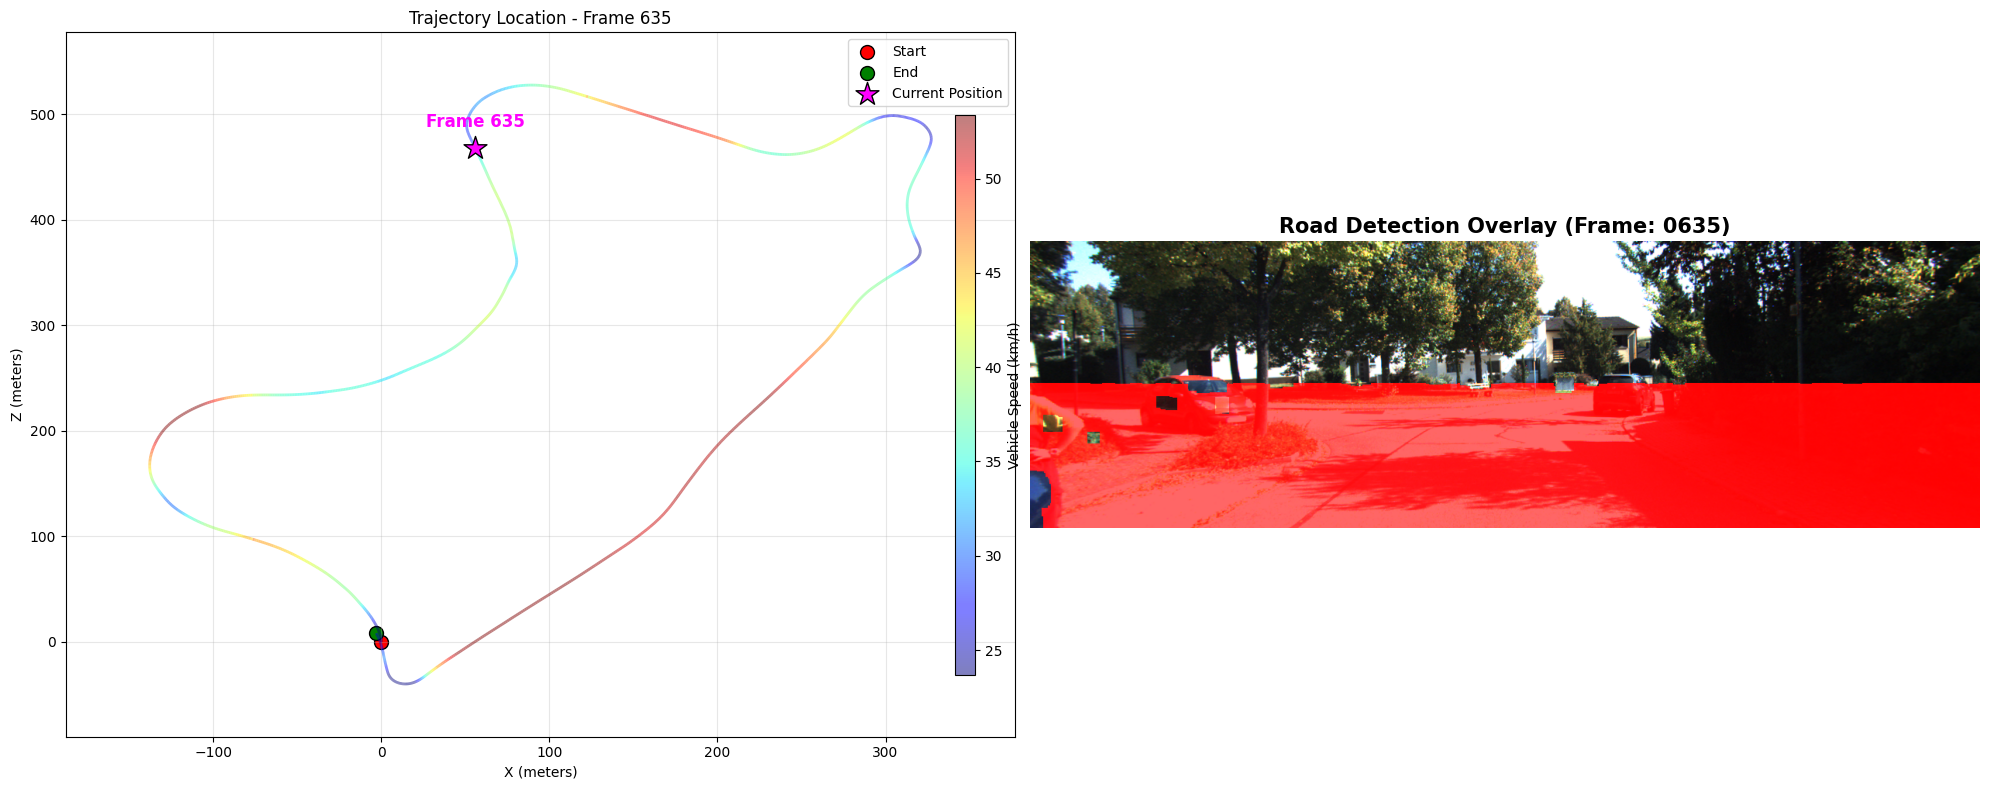

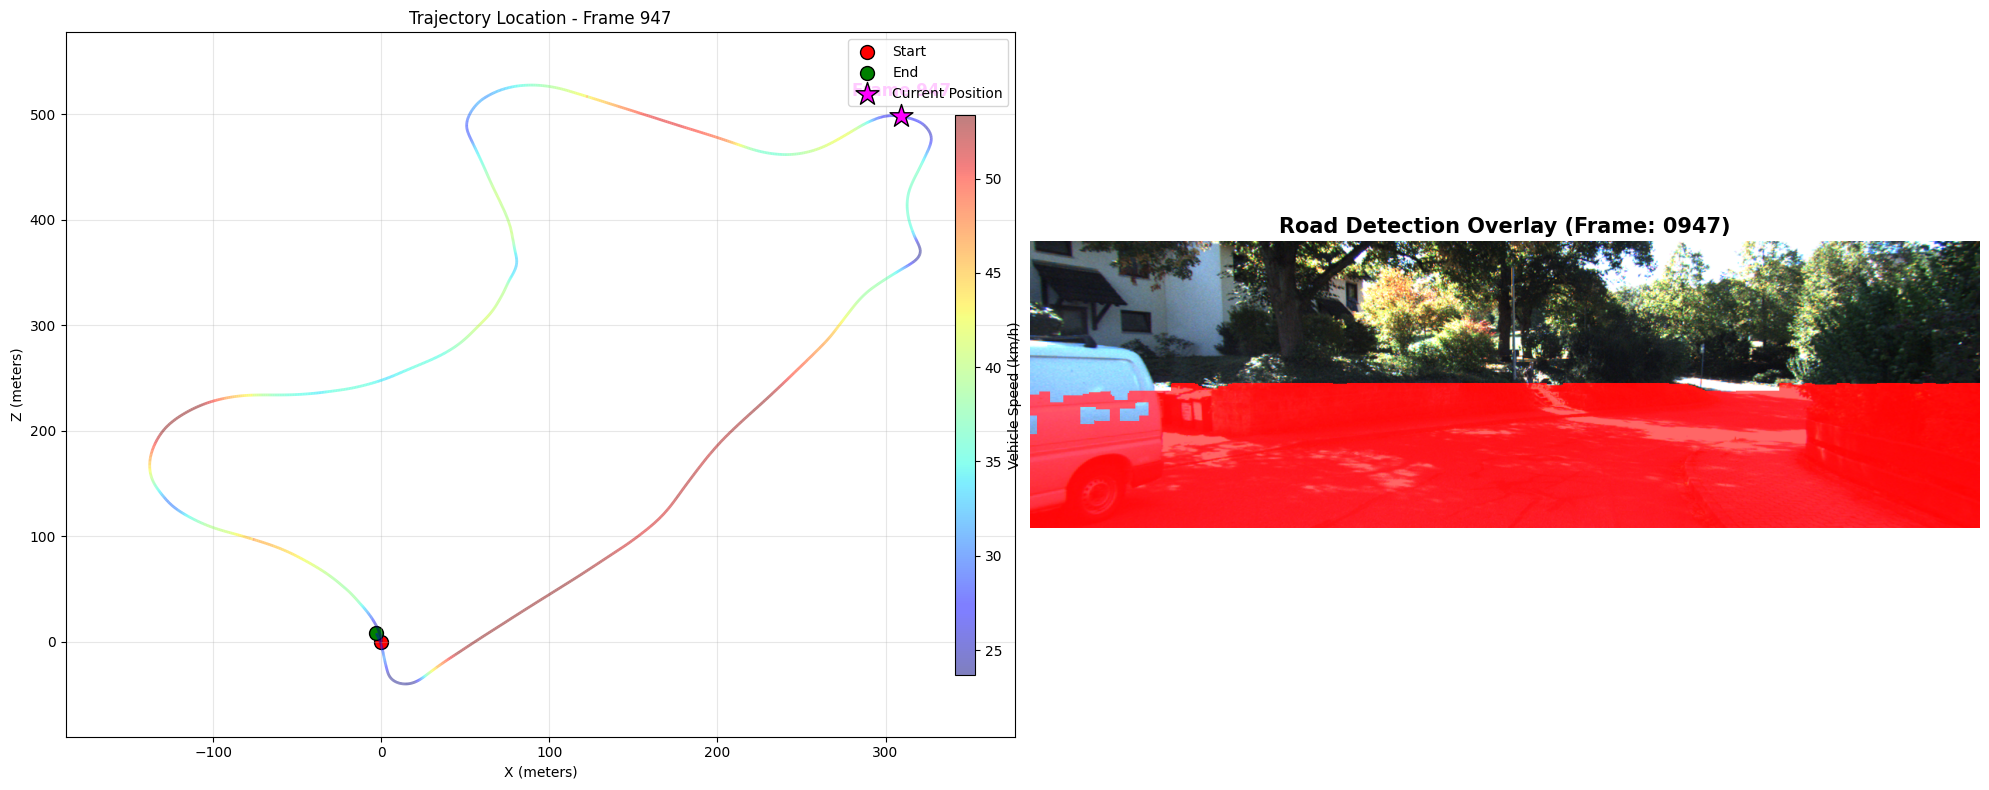

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.collections import LineCollection
from PIL import Image

# 1. 설정 및 데이터 로드
base_path = './dataset/poses/'
overlay_path = './outputs/bayes_road_09_projection/frames/' # Overlay 이미지가 저장된 폴더
seq = '09'
file_path = os.path.join(base_path, f'{seq}.txt')

# 포즈 데이터 읽기
poses = pd.read_csv(file_path, delimiter=' ', header=None)
gt = np.zeros((len(poses), 3, 4))
for i in range(len(poses)):
    gt[i] = np.array(poses.iloc[i]).reshape((3, 4))

x = gt[:, 0, 3]
y = gt[:, 1, 3]
z = gt[:, 2, 3]

# 속도 계산
dists = np.sqrt(np.diff(x)**2 + np.diff(y)**2 + np.diff(z)**2)
speeds = dists * 10 * 3.6
speeds = np.append(speeds, speeds[-1])
v_min, v_max = np.percentile(speeds, [5, 95])
norm = plt.Normalize(v_min, v_max)

target_indices = [635,947] # 이곳에 원하는 프레임 번호를 넣으세요
# -------------------------------

for target_idx in target_indices:
    # 2. 이미지 로드 (파일 이름 형식 000500.png 대응)
    frame_name = str(target_idx).zfill(4)
    img_file = os.path.join(overlay_path, f'frame_{frame_name}.png')

    overlay_img = Image.open(img_file)

    # 3. 그래프 그리기 (1행 2열 구성)
    fig = plt.figure(figsize=(20, 8))
    ax1 = fig.add_subplot(121)
    
    # 전체 궤적 그리기
    points_2d = np.array([x, z]).T.reshape(-1, 1, 2)
    segments_2d = np.concatenate([points_2d[:-1], points_2d[1:]], axis=1)
    lc2d = LineCollection(segments_2d, cmap='jet', norm=norm, alpha=0.5)
    lc2d.set_array(speeds)
    lc2d.set_linewidth(2)
    ax1.add_collection(lc2d)
    
    # 시작/끝점 표시
    ax1.scatter(x[0], z[0], color='red', s=100, label='Start', edgecolors='black')
    ax1.scatter(x[-1], z[-1], color='green', s=100, label='End', edgecolors='black')

    # 현재 인덱스 위치 표시 (눈에 띄는 자홍색 별 모양)
    ax1.scatter(x[target_idx], z[target_idx], color='magenta', marker='*', s=300, 
                label='Current Position', edgecolors='black', zorder=15)
    
    # 현재 위치에 텍스트 표시
    ax1.annotate(f'Frame {target_idx}', (x[target_idx], z[target_idx]), 
                 textcoords="offset points", xytext=(0,15), ha='center', 
                 fontsize=12, fontweight='bold', color='magenta')

    ax1.set_xlim(x.min()-50, x.max()+50)
    ax1.set_ylim(z.min()-50, z.max()+50)
    ax1.set_xlabel('X (meters)')
    ax1.set_ylabel('Z (meters)')
    ax1.set_title(f'Trajectory Location - Frame {target_idx}')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # [우측: Overlay 이미지 출력]
    ax2 = fig.add_subplot(122)
    ax2.imshow(overlay_img)
    ax2.set_title(f"Road Detection Overlay (Frame: {frame_name})", fontsize=15, fontweight='bold')
    ax2.axis('off') # 이미지 축 숨기기
    cbar_ax = fig.add_axes([0.48, 0.15, 0.01, 0.7])
    fig.colorbar(lc2d, cax=cbar_ax, label='Vehicle Speed (km/h)')

    plt.tight_layout()
    plt.show()

## 답변5
### 실패구간- Frame 635, 947 궤적
### 실패 원인 분석
1. 조명 변화 및 그림자가 존재
   - 두 프레임 모두 울창한 가로수 아래를 지나며 도로 위에 강한 격자형 그림자가 형성되어 있습니다. 베이지안 분류기는 픽셀의 HSV 값을 바탕으로 확률을 계산합니다. 그림자 안의 아스팔트는 '어둡고 채도가 낮은' 특성을 갖는데, 이는 도로 옆의 어두운 수풀이나 건물의 그늘진 벽면과 색상 통계적으로 매우 유사합니다.
   - 결과적으로, 그림자 영역과 배경(수풀)을 구분하지 못해 빨간색 오버레이가 도로 바깥(왼쪽 수풀, 오른쪽 건물)까지 과도하게 확장되었습니다.
2. 도로 질감 변화가 없음
   - 도로 경계석이나 인도의 색상이 아스팔트의 회색조와 거의 일치할 경우, 색상 히스토그램만으로는 이를 분리할 수 없습니다.
   - 결과적으로, Frame 635에서 보듯 도로와 인접한 수풀 사이의 경계선이 무너지고, 질감이 유사한 영역이 모두 도로로 오검출되었습니다.
3. 차량의 회전 및 경사
   - Frame 635는 좌회전, Frame 947은 급격한 우회전 상황입니다.차량이 회전하면 물리적인 소실점은 이미지의 중앙에서 벗어나 좌우로 크게 이동합니다. 하지만 현재 코드는 카메라 행렬에서 계산된 고정된 소실점을 기준으로 마스크를 생성합니다.
   - 실제 도로는 화면의 옆으로 휘어져 있는데, 알고리즘은 소실점 높이를 기준으로 수평하게 상단을 잘라버리는 결과를 낳습니다. 이로 인해 이미지 상단에 부자연스러운 수평 일직선 마스크가 형성된 것입니다.
   - 차선이 사다리꼴 ROI를 벗어나 급격히 휘어지기 때문에 Hough 변환이 직선을 찾지 못하고, 지저분한 베이지안 마스크 결과가 출력된 것입니다.